# Notebook to see how the field profiles look and answer to the reviewer

Set variables and evironmet

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 2.5         
N = 64 
tau_sim = 1.25    
DTS = 8

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_sim / a * DTS)
nplus = maxt//DTS     

# Glasma fields
su_group = 'su3'
Qs = 2        
ns = 50    
factor = 0.68        
g2mu = Qs / factor     
g = np.pi * np.sqrt(1 / np.log(Qs / 0.2))          		
mu = g2mu / g**2          	
ir = 0.2 * g**2 * mu         
uv = 10.0       


nevents = 1 # We just need an event for this check

In [2]:
import os

os.environ["MY_NUMBA_TARGET"] = "numba"
os.environ["PRECISION"] = "double"
os.environ['GAUGE_GROUP'] = su_group

# Import relevant modules
import sys
sys.path.append('..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

import curraun.su as su
from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

import curraun.su as su

Using Numba
Using SU(3)
Using double precision


/home2/carlos.lamas/condacurraun/lib/python3.10/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 1.21.5)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Define the simulation routine

In [3]:
from tqdm import tqdm 

# Simulation routine
def simulate():
    
    # Dictionary to store the results
    output = {}
    
    # Derived parameters
    a = L/N
    E0 = N/L*hbarc
    DT = 1.0/DTS 
    maxt = int(tau_sim/a*DTS)
    
    # We create the object Glasma Simulation
    s = core.Simulation(N, DT, g)
    
    # We intialize the Glasma fields
    va = mv.wilson(s, mu=mu/E0, m=ir/E0, uv=uv/E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu/E0, m=ir/E0, uv=uv/E0, num_sheets=ns)
    initial.init(s, va, vb)
    
    # We create an object to store the fields at every time step
    ux_sim = np.zeros((maxt, N, N, su.GROUP_ELEMENTS), dtype=su.GROUP_TYPE)
    uy_sim = np.zeros((maxt, N, N, su.GROUP_ELEMENTS), dtype=su.GROUP_TYPE)
    aeta_sim = np.zeros((maxt, N, N, su.GROUP_ELEMENTS), dtype=su.GROUP_TYPE)

    
    # We first simulate the Glasma event and store the fields at every time step
    with tqdm(total=maxt) as pbar:
        for t in range(maxt):
        
            # Evolve the Glasma fields
            core.evolve_leapfrog(s)
        
            # Store the fields at every time step
            u1 = s.u1.copy()
            ux_sim[t] = u1[:, 0, :].reshape(N, N, su.GROUP_ELEMENTS)
            uy_sim[t] = u1[:, 1, :].reshape(N, N, su.GROUP_ELEMENTS)
        
            aeta = s.aeta1.copy()
            aeta_sim[t] = aeta.reshape(N, N, su.GROUP_ELEMENTS)
        
            pbar.update(1)
            
    if use_cuda:
        cuda.current_context().deallocations.clear()
    
    
    output['ux'] = ux_sim
    output['uy'] = uy_sim
    output['aeta'] = aeta_sim
    
    return output

Perform the simulation

In [4]:

import warnings
warnings.filterwarnings('ignore')

for n in range (nevents):
    
    output = simulate()
    
    ux = output['ux']
    uy = output['uy']
    aeta = output['aeta']
    
    # np.save(os.path.join('simulations', 'ux_lc', 'result_%i.npy' %n), up_jetsim)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
100%|██████████| 256/256 [00:02<00:00, 95.13it/s] 


Extract the color componets

In [5]:

ux_comp = np.apply_along_axis(su.get_algebra_factors_from_group_element_approximate, 3, ux)
uy_comp = np.apply_along_axis(su.get_algebra_factors_from_group_element_approximate, 3, uy)
aeta_comp = np.apply_along_axis(su.get_algebra_factors_from_group_element_approximate, 3, aeta)

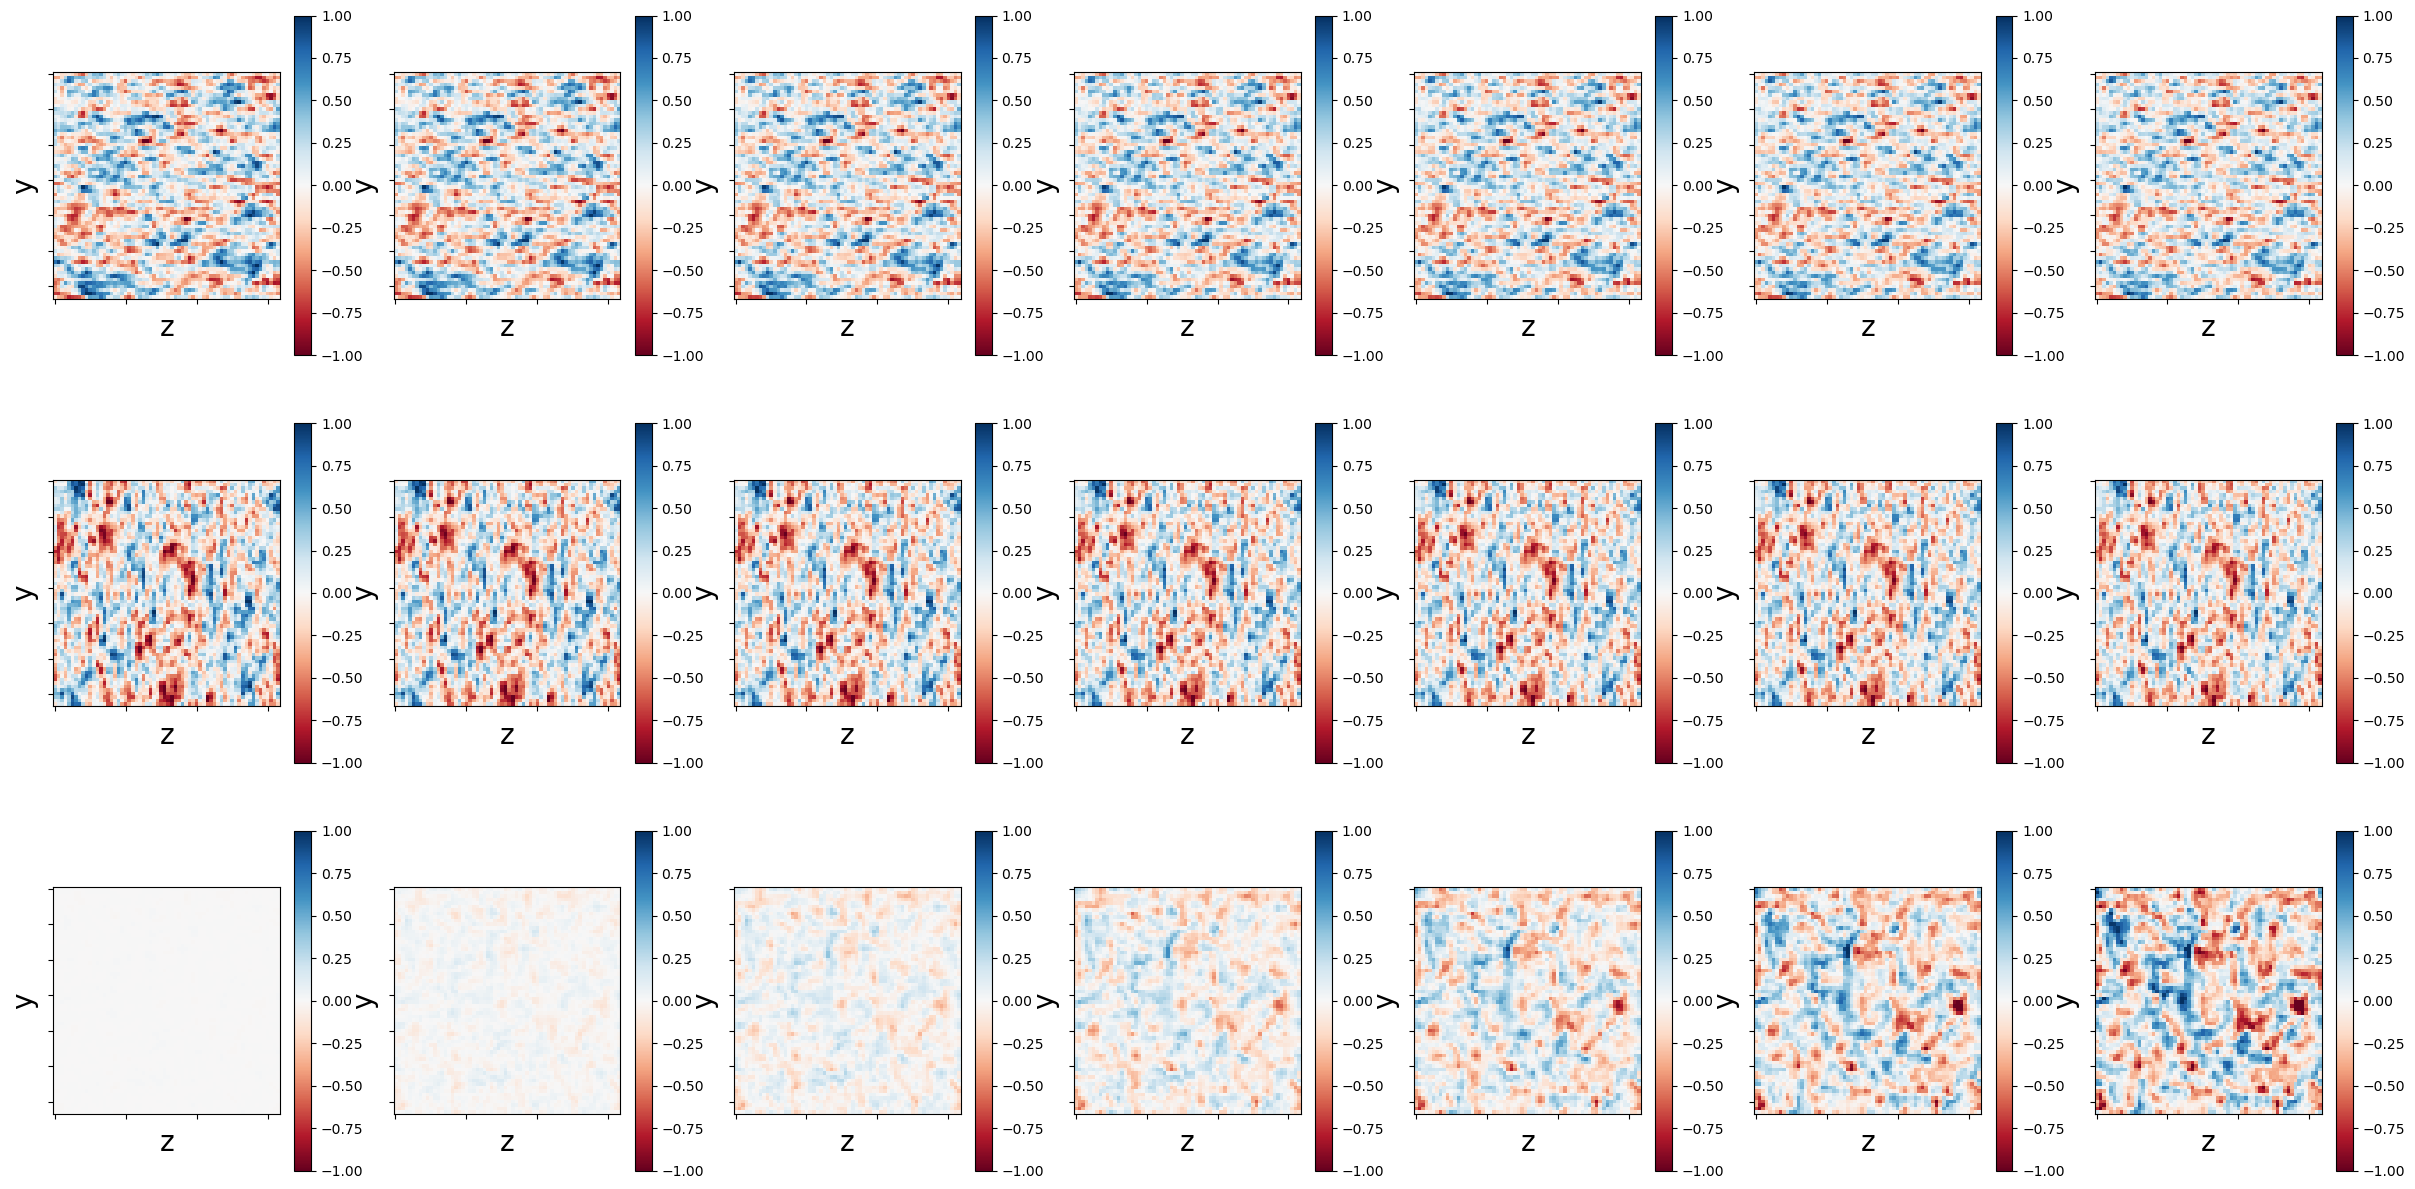

In [6]:
# We plot the reordered temporal gauge results
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, nplus//5 +1, figsize=(30,15))
# fig.suptitle(r'$U_+^{temp}(x^+, y, z)$', fontsize=20)

for t in range(nplus//5 + 1): 
    tau = 5*t
    
    plot1 = axs[0, t].imshow(ux_comp[tau, :, :, 0].real, cmap='RdBu', vmin=-1, vmax=1) 
    cbar = plt.colorbar(plot1, ax = axs[0,t])
    
    axs[0,t].set_xticklabels([]); axs[0,t].set_yticklabels([])
    axs[0,t].set_ylabel('y', fontsize=20); axs[0,t].set_xlabel('z', fontsize=20)
    
    plot2 = axs[1, t].imshow(uy_comp[tau, :, :, 0].real, cmap='RdBu', vmin=-1, vmax=1)
    cbar = plt.colorbar(plot2, ax = axs[1,t])
    
    axs[1,t].set_xticklabels([]); axs[1,t].set_yticklabels([])
    axs[1,t].set_ylabel('y', fontsize=20); axs[1,t].set_xlabel('z', fontsize=20)
    
    plot3 = axs[2, t].imshow(aeta_comp[tau, :, :, 0].real, cmap='RdBu', vmin=-1, vmax=1)
    cbar = plt.colorbar(plot3, ax = axs[2,t])
    
    axs[2,t].set_xticklabels([]); axs[2,t].set_yticklabels([])
    axs[2,t].set_ylabel('y', fontsize=20); axs[2,t].set_xlabel('z', fontsize=20)
    
# plt.savefig('temporal_gauge_fields', bbox_inches='tight')